In [1]:
from datasets import load_dataset
import json
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

In [2]:
delta_sec = [0.05, 0.10, 0.20, 0.50, 1.00, 2.00, 5.00]

In [ ]:
dataset = load_dataset("CAiRE/ASCEND")

with open("outputs/code_switch_timestamps.json", "r") as f:
    code_switch_timestamps = json.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00003.parquet:   0%|          | 0.00/317M [00:00<?, ?B/s]

main/train-00001-of-00003.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

main/train-00002-of-00003.parquet:   0%|          | 0.00/328M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

main/validation-00000-of-00001.parquet:   0%|          | 0.00/107M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9869 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1315 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1130 [00:00<?, ? examples/s]

cuda


In [4]:
wav2vec2_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
wav2vec2_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device)
wav2vec2_model.eval()

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [5]:
def get_switch_ground_truth(split, idx, delta_sec):

    sample = dataset[split][idx]

    switches = []
    for item in code_switch_timestamps[split]:
        if item["index"] == idx:
            for switch in item["switches"]:
                switches.append(switch["switch"])
            break

    waveform = torch.tensor(sample["audio"]["array"], dtype=torch.float32).unsqueeze(0)
    sample_rate = sample["audio"]["sampling_rate"]

    inputs = wav2vec2_processor(
        waveform.squeeze(0).numpy(),
        sampling_rate=sample_rate,
        return_tensors="pt"
    )
    
    input_values = inputs.input_values.to(device)
    
    with torch.inference_mode():
        outputs = wav2vec2_model(
            input_values,
            output_hidden_states=False
        )
    
    wv_num_frames = outputs.last_hidden_state.size(1)
    samples_per_frame = input_values.size(1) / wv_num_frames
    seconds_per_frame = samples_per_frame / sample_rate
    
    frame_times = np.arange(wv_num_frames) * seconds_per_frame
    
    y = {}
    
    for delta in delta_sec:
        
        y[delta] = []
        
        for frame_time in frame_times:
        
            future_switches = [
                switch for switch in switches
                if switch > frame_time
            ]
        
            if len(future_switches) == 0:
                y[delta].append(0)
                continue
        
            next_switch = min(future_switches)
        
            if next_switch - frame_time <= delta:
                y[delta].append(1)
            else:
                y[delta].append(0)
        
        y[delta] = np.array(y[delta])
        
    return y

In [6]:
ground_truth = {}
failures = []

for split in dataset.keys():

    ground_truth[split] = []

    for idx, sample in enumerate(tqdm(dataset[split], desc=split)):

        if sample["language"] != "mixed":
            continue

        if "[UNK]" in sample["transcription"]:
            continue

        try:
            y = get_switch_ground_truth(split, idx, delta_sec)

            ground_truth[split].append({
                "index": idx,
                "y": y
            })

        except Exception as e:
            failures.append({
                "split": split,
                "index": idx,
                "error": str(e)
            })

train:   0%|          | 0/9869 [00:00<?, ?it/s]

test:   0%|          | 0/1315 [00:00<?, ?it/s]

validation:   0%|          | 0/1130 [00:00<?, ?it/s]

Delta:  0.05

Test metrics:
roc_auc: 0.500
ap: 0.027
log_loss: 0.123
brier_score: 0.026


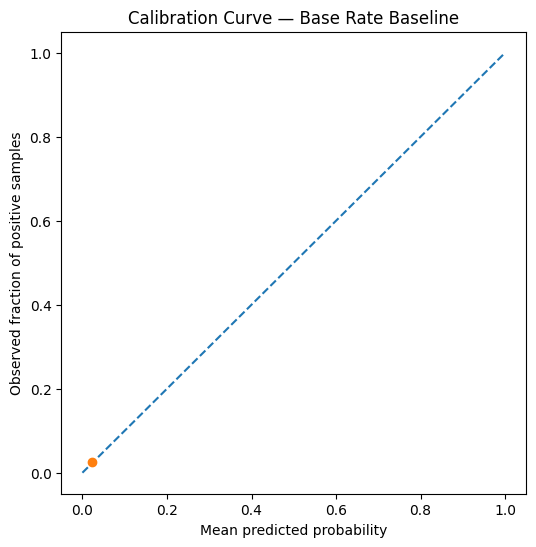

Delta:  0.1

Test metrics:
roc_auc: 0.500
ap: 0.049
log_loss: 0.197
brier_score: 0.047


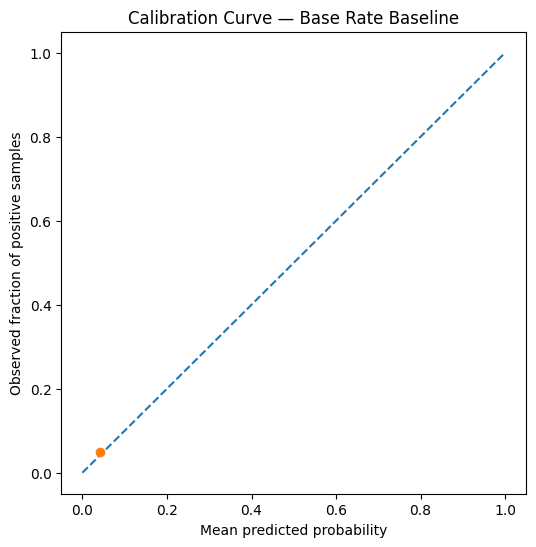

Delta:  0.2

Test metrics:
roc_auc: 0.500
ap: 0.102
log_loss: 0.330
brier_score: 0.092


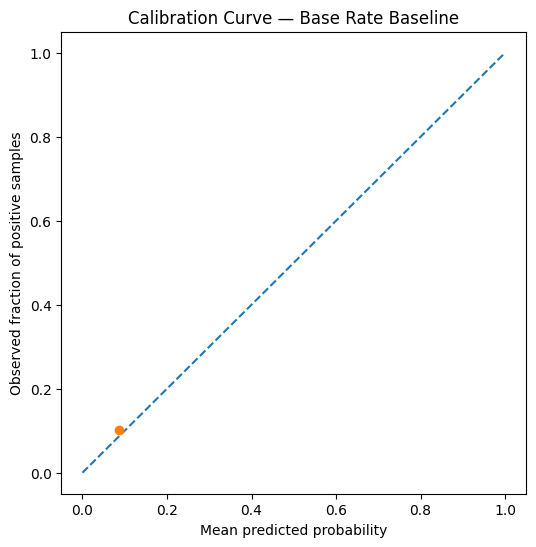

Delta:  0.5

Test metrics:
roc_auc: 0.500
ap: 0.247
log_loss: 0.564
brier_score: 0.188


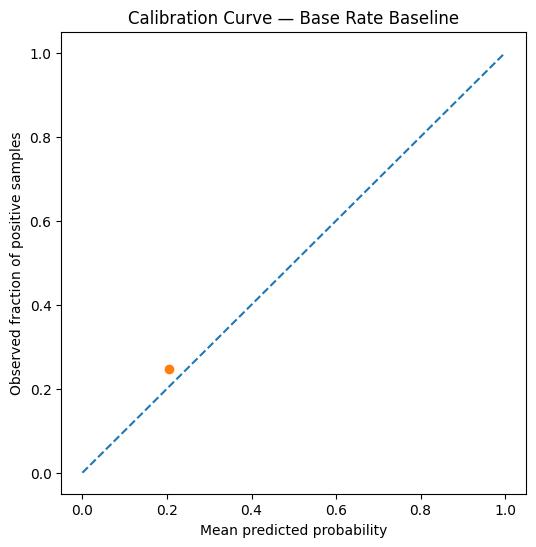

Delta:  1.0

Test metrics:
roc_auc: 0.500
ap: 0.400
log_loss: 0.682
brier_score: 0.244


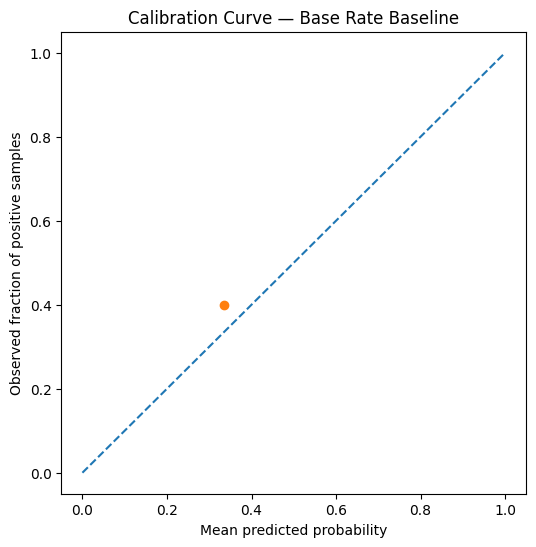

Delta:  2.0

Test metrics:
roc_auc: 0.500
ap: 0.552
log_loss: 0.700
brier_score: 0.254


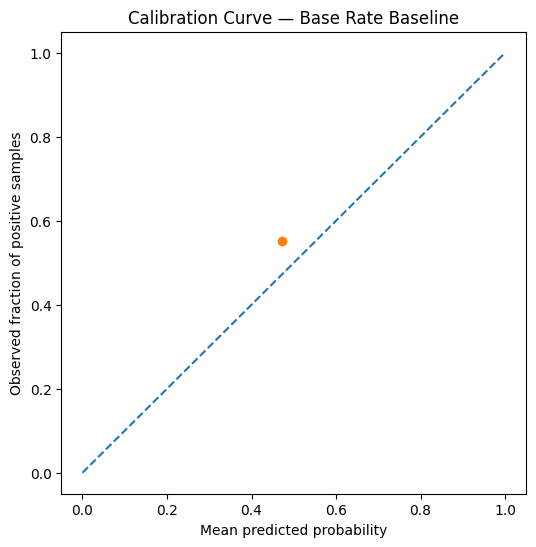

Delta:  5.0

Test metrics:
roc_auc: 0.500
ap: 0.671
log_loss: 0.643
brier_score: 0.225


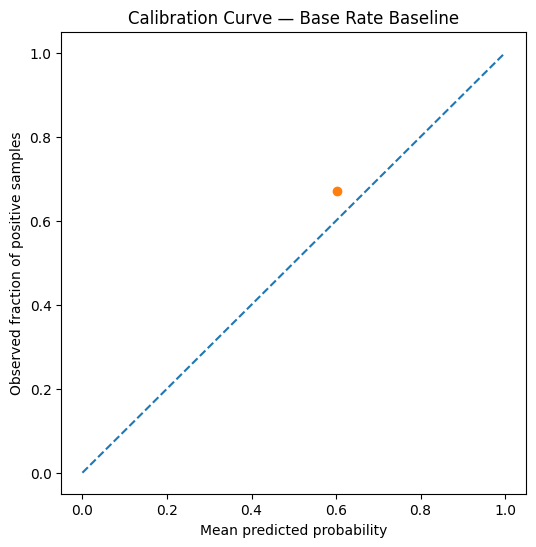

In [7]:
results = {}

for delta in delta_sec:
    print("Delta: ", delta)

    y = {}

    for split in dataset.keys():
        
        y[split] = []

        for gt in ground_truth[split]:
            
            y_sample = gt["y"][delta]
            y[split].append(y_sample)
            
        y[split] = np.concatenate(y[split], axis=0)

    y_train = y["train"]
    
    y_test = y["test"]

    base_rate = np.mean(y_train)

    test_prob = np.full(len(y_test), base_rate)

    test_metrics = {
        "roc_auc": float(roc_auc_score(y_test, test_prob)),
        "ap": float(average_precision_score(y_test, test_prob)),
        "log_loss": float(log_loss(y_test, test_prob)),
        "brier_score": float(brier_score_loss(y_test, test_prob))
    }
    
    print("\nTest metrics:")
    for metric, value in test_metrics.items():
        print(f"{metric}: {value:.3f}")

    prob_true, prob_pred = calibration_curve(
        y_test,
        test_prob,
        n_bins=10
    )
    
    plt.figure(figsize=(6, 6))
    
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(prob_pred, prob_true, marker="o")

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed fraction of positive samples")
    plt.title("Calibration Curve — Base Rate Baseline")
    
    plt.show()

    results[delta] = {
        "delta_sec": delta,
        "base_rate": base_rate,
        "metrics": test_metrics
    }

In [ ]:
with open("outputs/b1_base_rate_results.json", "w") as f:
    json.dump(results, f, indent=2)